In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, confusion_matrix, roc_curve,auc, roc_auc_score
from sklearn.preprocessing import label_binarize

In [11]:
df = pd.read_csv(
    r"C:\Users\Lucca\Documents\New project\nubank-sentiment-analysis\data\processed\textual_dataset_preprocessed.csv",
    encoding="utf-8"
)

df_train = df[df["sentimento_real"].notna()].copy()
df_pred = df[df["sentimento_real"].isna()].copy()

print(df_train.shape)
print(df_pred.shape)
print(df_train["sentimento_real"].value_counts())

(38698, 12)
(13710, 12)
sentimento_real
Positivo    29292
Negativo     7858
Neutro       1548
Name: count, dtype: int64


In [12]:
X = df_train["texto_limpo"]
y = df_train["sentimento_real"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

vectorizer = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1, 2),
    min_df=2,
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print(X_train_tfidf.shape)
print(X_test_tfidf.shape)

(30958, 20000)
(7740, 20000)


In [13]:
models = {
    "LogisticRegression": LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=42,
    ),
    "MultinomialNB": MultinomialNB(),
    "LinearSVC": LinearSVC(
        class_weight="balanced",
        random_state=42,
    ),
}

In [14]:
classes = ["Negativo", "Neutro", "Positivo"]

results = {}
roc_inputs = {}

y_test_bin = label_binarize(y_test, classes=classes)

for name, model in models.items():
    model.fit(X_train_tfidf, y_train)
    y_pred = model.predict(X_test_tfidf)

    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test_tfidf)
    else:
        y_score = model.decision_function(X_test_tfidf)

    roc_auc_macro = roc_auc_score(
        y_test_bin,
        y_score,
        multi_class="ovr",
        average="macro",
    )

    roc_auc_weighted = roc_auc_score(
        y_test_bin,
        y_score,
        multi_class="ovr",
        average="weighted",
    )

    results[name] = {
        "classification_report": classification_report(y_test, y_pred, zero_division=0),
        "confusion_matrix": confusion_matrix(y_test, y_pred),
        "roc_auc_macro": roc_auc_macro,
        "roc_auc_weighted": roc_auc_weighted,
    }

    roc_inputs[name] = {
        "y_score": y_score,
        "y_pred": y_pred,
    }

    print(f"\n### {name}")
    print(results[name]["classification_report"])
    print(results[name]["confusion_matrix"])
    print("ROC AUC macro:", roc_auc_macro)
    print("ROC AUC weighted:", roc_auc_weighted)


### LogisticRegression
              precision    recall  f1-score   support

    Negativo       0.70      0.81      0.75      1572
      Neutro       0.15      0.28      0.20       309
    Positivo       0.97      0.88      0.93      5859

    accuracy                           0.85      7740
   macro avg       0.61      0.66      0.63      7740
weighted avg       0.88      0.85      0.86      7740

[[1277  206   89]
 [ 159   88   62]
 [ 400  276 5183]]
ROC AUC macro: 0.8790850561672463
ROC AUC weighted: 0.9392307527883911

### MultinomialNB
              precision    recall  f1-score   support

    Negativo       0.72      0.82      0.77      1572
      Neutro       0.00      0.00      0.00       309
    Positivo       0.93      0.95      0.94      5859

    accuracy                           0.88      7740
   macro avg       0.55      0.59      0.57      7740
weighted avg       0.85      0.88      0.87      7740

[[1291    0  281]
 [ 172    0  137]
 [ 318    0 5541]]
ROC AUC macro:

In [15]:
comparison_rows = []

for name, result in results.items():
    report = classification_report(
        y_test,
        roc_inputs[name]["y_pred"],
        output_dict=True,
        zero_division=0,
    )

    comparison_rows.append(
        {
            "modelo": name,
            "accuracy": report["accuracy"],
            "f1_macro": report["macro avg"]["f1-score"],
            "precision_macro": report["macro avg"]["precision"],
            "recall_macro": report["macro avg"]["recall"],
            "roc_auc_macro": result["roc_auc_macro"],
            "roc_auc_weighted": result["roc_auc_weighted"],
        }
    )

df_comparison = pd.DataFrame(comparison_rows).sort_values(
    by=["f1_macro", "roc_auc_macro"],
    ascending=False,
)

df_comparison

,modelo,accuracy,f1_macro,precision_macro,recall_macro,roc_auc_macro,roc_auc_weighted
0,LogisticRegression,0.845995,0.625252,0.607204,0.660584,0.879085,0.939231
2,LinearSVC,0.871059,0.621915,0.617336,0.629105,0.860701,0.937891
1,MultinomialNB,0.882687,0.569260,0.551576,0.588990,0.888782,0.939317


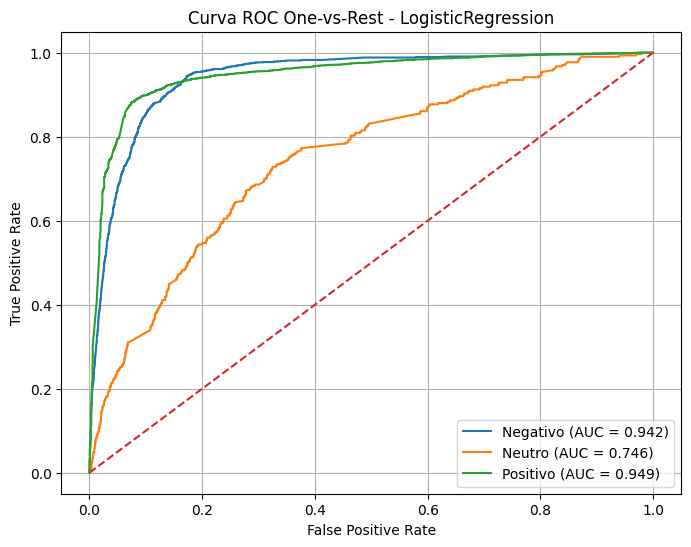

In [16]:
model_name = "LogisticRegression"
y_score = roc_inputs[model_name]["y_score"]

fpr = {}
tpr = {}
roc_auc = {}

for i, class_name in enumerate(classes):
    fpr[class_name], tpr[class_name], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[class_name] = auc(fpr[class_name], tpr[class_name])

plt.figure(figsize=(8, 6))

for class_name in classes:
    plt.plot(
        fpr[class_name],
        tpr[class_name],
        label=f"{class_name} (AUC = {roc_auc[class_name]:.3f})"
    )

plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"Curva ROC One-vs-Rest - {model_name}")
plt.legend()
plt.grid(True)
plt.show()

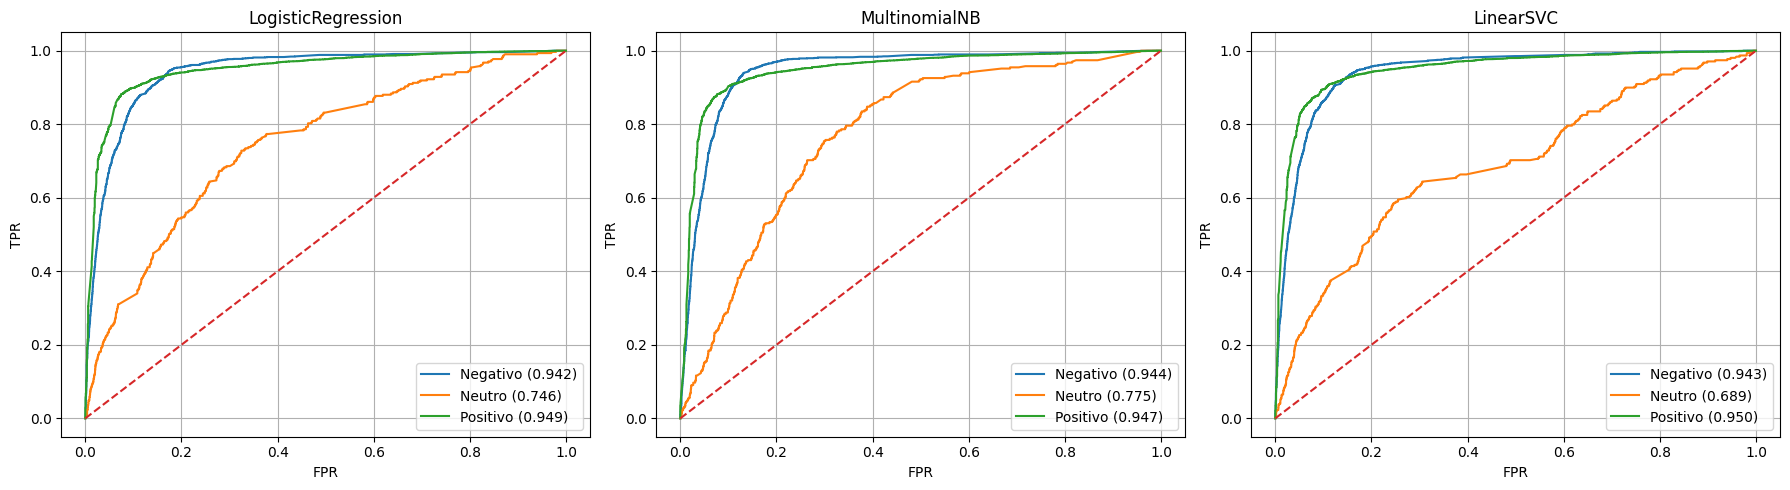

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, model_name in zip(axes, models.keys()):
    y_score = roc_inputs[model_name]["y_score"]

    for i, class_name in enumerate(classes):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
        roc_auc_value = auc(fpr, tpr)

        ax.plot(fpr, tpr, label=f"{class_name} ({roc_auc_value:.3f})")

    ax.plot([0, 1], [0, 1], linestyle="--")
    ax.set_title(model_name)
    ax.set_xlabel("FPR")
    ax.set_ylabel("TPR")
    ax.grid(True)
    ax.legend()

plt.tight_layout()
plt.show()

In [18]:
best_model_name = df_comparison.iloc[0]["modelo"]
best_model = models[best_model_name]

X_youtube = vectorizer.transform(df_pred["texto_limpo"])
df_pred["sentimento_previsto"] = best_model.predict(X_youtube)

print(best_model_name)
print(df_pred["sentimento_previsto"].value_counts())

LogisticRegression
sentimento_previsto
Negativo    7380
Positivo    4800
Neutro      1530
Name: count, dtype: int64


In [19]:
output_path = rf"C:\Users\Lucca\Documents\New project\nubank-sentiment-analysis\data\processed\youtube_with_predicted_sentiment_{best_model_name}.csv"
df_pred.to_csv(output_path, index=False, encoding="utf-8-sig")
print(output_path)


C:\Users\Lucca\Documents\New project\nubank-sentiment-analysis\data\processed\youtube_with_predicted_sentiment_LogisticRegression.csv
